# 4. Four cameras: now the offset can be learned

Notebook 2 could predict a pose-dependent displacement from the robot's shape, but one
camera could not estimate a constant offset separately from absolute position. Multiple
cameras constrain the **differences** between their offsets. They do not remove the common
translation ambiguity; this notebook keeps that limitation explicit.

---

**What this notebook implements**

The offset carried in the state, one 2-D vector per camera: the state grows from 2 numbers to 10, and $H_c$ picks out the position plus whichever camera fired (`nm.offset_state_filter`). Broad 10 cm prior, optionally a slow random walk. Scored against the geometric prediction from notebook 2 and against a ground-truth ceiling.

**What came out**

On diagnostic run `notebook_5hz` with current plain floor IPM, filter-belief median NEES
versus Gazebo `gt_x/gt_y` over 998 grid/update steps moves **25.9 → 0.74**, versus the
calibrated 2-D reference 1.386. Thus the resulting belief is conservative, not exactly
calibrated. Across the four cameras, the median Euclidean difference between final offset
posterior mean and the evaluation-only run-mean measurement residual is still **3.3 cm**.
Prediction and state estimation fail in different
places: the predictor is 1.8–3.4 cm on A, C, D but 9.4 cm on B, the most-occluded camera,
where the augmented-state estimate is closer to the evaluation-only run mean.

**What to do about it**

> **Predict the pose-dependent geometry; estimate a residual state with uncertainty.**
> Even with four cameras, the offset component common to all cameras is unobservable.
> Relative offsets are constrained only when the route makes the camera–time observation
> graph connected.

---

Here “learn the offset” means **recursive Bayesian state estimation** by
`nm.offset_state_filter`. There is no loss-minimising optimiser and no 12-pass variational
loop. The function makes one chronological Kalman pass over 998 time steps. At each step it
predicts the 10-D state; if camera $c$ reports, it performs one linear-Gaussian update of
position and that camera's offset block.

**Evidence scope.** The run is `notebook_5hz`, under current plain floor IPM. Online inputs
are odometry, camera identity and projected measurements. `gt_x/gt_y` is used only for
filter-belief NEES/RMSE and for the diagnostic run-mean residual targets. This is not a
balanced A–D camera-accuracy comparison.

In [1]:
import notebook_data as nd
import notebook_model as nm
import notebook_views as nv
import numpy as np

nv.style()
commissioned = nm.commissioned_noise()

## 1. The run, and all four cameras

In [2]:
capture = nd.load_capture()
truth_table = nd.load_truth(capture.name)
models = nd.camera_models()
window = nd.route_window(capture.name)
seq = nm.Sequence(capture, truth_table, window=window)
n_obs = int(seq.observed.sum())

nv.report_sequence(seq, n_obs, window, capture, truth_table)

driven route: simulated seconds 111.8 to 211.5 (100 s)
grid:          998 steps at 10 Hz (100 s)
observed:      349 steps (35%)
unobserved:    649 steps (65%) -- these are pure prediction
truth present: 998 steps

  A:   88 of the observed steps
  B:   36 of the observed steps
  C:  160 of the observed steps
  D:   65 of the observed steps


### So what *is* the offset, exactly?

It is worth being precise, because the word has been doing a lot of work.

Two different points are being compared:

* **What the pipeline reports** — the floor point that the bottom-centre pixel of the
  detector's box back-projects to.
* **What ground truth reports** — the robot's own origin, `base_footprint`, which sits on
  the floor at the midpoint of the wheel axis.

Once the filter declares `base_footprint` to be its target, their difference is a camera
measurement residual:

$$\mathbf e_{c,k}=\mathbf y_{c,k}-\mathbf x_k^{\mathrm{GT}}.$$

We reserve **constant offset** for the sample mean
$\mathbf b_c=n_c^{-1}\sum_k\mathbf e_{c,k}$ on a named dataset. It is a summary, not a
claim that every residual is constant or that it transfers to another route. The
pose-dependent geometric prediction from notebook 2 remains
$\mathbf d_c(\mathbf x,\theta)=g_c(\mathbf x,\theta)-\mathbf x$.

**In this dataset, that is nearly the whole story.** It is worth stating what is *not*
contributing, because a real installation would have more:

| possible cause | active here? |
|---|---|
| the box bottom is not the declared robot origin | **yes — systematic residual source** |
| camera pose wrong | no: the model is built from the same world file the renderer uses |
| lens distortion | no: the camera definitions carry no distortion term |
| floor not at $z=0$ | no: in this world it is exactly $z = 0$ |
| shadow read as part of the robot | possibly, at the margin |
| the silhouette clipped by a shelf | **yes — and this is the residual, see below** |

So the description is narrower and more useful than “cameras have biases”: the
detector reports the bottom of a silhouette, the silhouette belongs to a 19 cm tall body
whose plan centroid sits 37 mm behind the robot's origin, and the pipeline treats that
report as if it were the origin itself. In a real building the middle three rows would
also be non-zero, and would be indistinguishable from this one in a single residual.

The next cell splits each residual into the part along the camera's ground-plane bearing
and the part perpendicular to it; these are not world $x/y$ components.

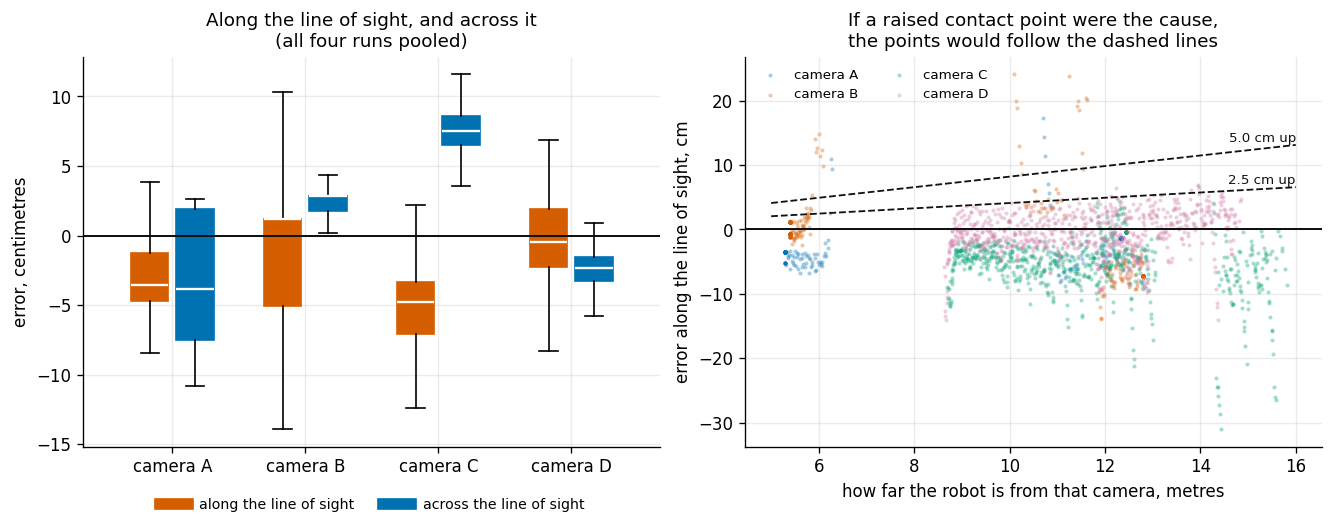

pooled over 2404 detections from four runs:
  along the line of sight: mean -2.21 cm, spread 4.63 cm
  across it:               mean +1.66 cm, spread 4.73 cm
  share of the squared error lying along the line of sight: 51%

  camera      across-track mean, per run (cm)


  A                 -    +1.4    -8.3    -6.7


  B              +2.6    +0.7    +2.6    +2.9


  C              +7.6    +8.8    +7.6    +6.7


  D              -2.3    -8.2    -2.3    -1.8


In [3]:
split = nm.decompose_errors(list(nd.COMMISSIONING_CAPTURES) + [capture.name], models)

nv.radial_and_tangential(split, capture, models)

Neither geometric story survives on its own, and that is the useful result.

The error divides almost evenly: about half of it lies along the line of sight and half
across it. A raised contact point can only produce the along-sight half, and it would
have to grow in proportion to range — the dashed guides in the right-hand panel. The
points do not follow them.

The across-track half is the more interesting one, because for cameras B and C it is
stable to about a centimetre across all four runs, and it is the component a small error
in where the camera is *aimed* would produce. But it is not stable for A and D, so that
does not close the case either.

What this rules out is the conclusion that one scalar mechanism explains the residual.
A constant $\mathbf b_c$ is only an approximation to several pose- and visibility-dependent
effects. We nevertheless estimate that approximation below to test whether explicitly
carrying a mean and its uncertainty is better than forcing all disagreement into $R$.

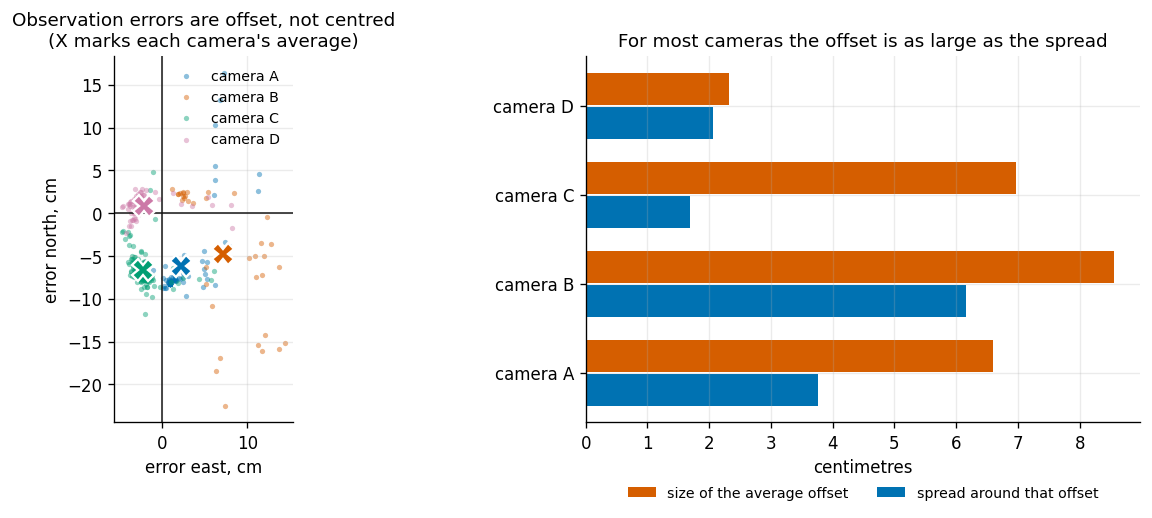

  camera A: average offset (  +2.2,   -6.2) cm, magnitude   6.6 cm, spread   3.8 cm, n=88
  camera B: average offset (  +7.1,   -4.7) cm, magnitude   8.6 cm, spread   6.2 cm, n=36
  camera C: average offset (  -2.2,   -6.6) cm, magnitude   7.0 cm, spread   1.7 cm, n=160
  camera D: average offset (  -2.1,   +0.9) cm, magnitude   2.3 cm, spread   2.1 cm, n=65


In [4]:
residuals = {cam: np.asarray([seq.y[i] - seq.truth[i] for i, c in enumerate(seq.camera)
                              if c == cam and np.isfinite(seq.truth[i, 0])])
             for cam in nd.CAMERAS}

nv.per_camera_residuals(residuals)

### Could the offset just be calibrated away?

The obvious response to a known per-camera offset is to measure it once and subtract
it forever. Commissioning measured exactly that, on three earlier runs. This capture
measures it again. If the offset were a fixed property of each camera, the two would
agree.

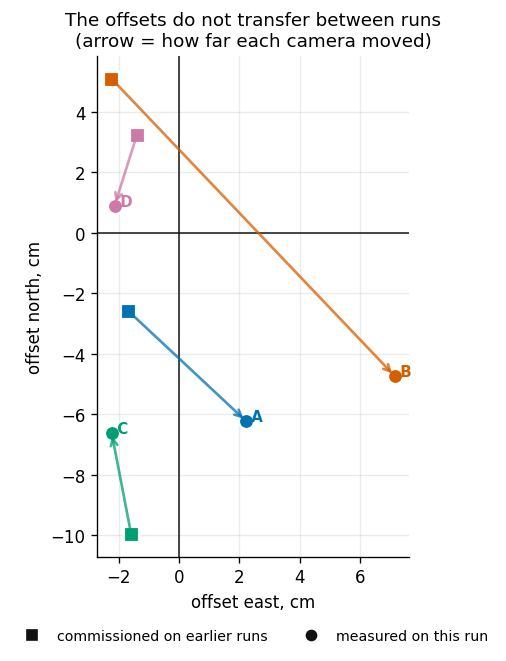

  camera                commissioned            this run   moved by
  A       (   -1.7,   -2.6) cm(   +2.2,   -6.2) cm      5.3 cm
  B       (   -2.2,   +5.1) cm(   +7.1,   -4.7) cm     13.6 cm
  C       (   -1.6,   -9.9) cm(   -2.2,   -6.6) cm      3.4 cm
  D       (   -1.4,   +3.2) cm(   -2.1,   +0.9) cm      2.4 cm


In [5]:
nv.offsets_do_not_transfer(residuals, commissioned["offset_m"])

## 2. Estimating constant offsets as part of the state

Notebook 2 computed a pose-dependent displacement from the robot's shape. That works because this robot's shape
is known and its heading is available. Neither is guaranteed — a different payload, an
unknown pallet, a camera whose survey has drifted, and the prediction is wrong.

So the other route is to put one constant offset approximation **in the state**. The state
grows from two numbers to ten,

$$\mathbf{z}_k = \begin{bmatrix}\mathbf{x}_k \\ \mathbf{b}^{(A)} \\ \mathbf{b}^{(B)} \\ \mathbf{b}^{(C)} \\ \mathbf{b}^{(D)}\end{bmatrix},
\qquad
\mathbf{y}_k = \underbrace{\begin{bmatrix} \mathbf{I} & \cdots & \mathbf{I} & \cdots \end{bmatrix}}_{H_c:\ \text{position plus that camera's offset}} \mathbf{z}_k + \mathbf{r}_k$$

where $H_c$ has an identity block on position and another on camera $c$'s offset. The
offsets get
a broad prior, $\mathbf{b}^{(c)} \sim \mathcal{N}(\mathbf{0}, (10\,\text{cm})^2\mathbf{I})$,
and optionally a random walk so they can track a quantity that is not really constant:
$\mathbf b^{(c)}_k=\mathbf b^{(c)}_{k-1}+\mathbf w^{(c)}_k$. “2 mm/step” means each
coordinate receives zero-mean process noise with 2 mm standard deviation at every 10 Hz
grid step; uncertainty grows while that camera is silent.

For an observation from $c$, `nm.offset_state_filter` computes

$$\mathbf v_k=\mathbf y_k-H_c\mathbf m_k^-,\quad
\mathbf S_k=H_c\mathbf P_k^-H_c^\top+\mathbf R_c,\quad
\mathbf K_k=\mathbf P_k^-H_c^\top\mathbf S_k^{-1},$$
$$\mathbf m_k=\mathbf m_k^-+\mathbf K_k\mathbf v_k,\qquad
\mathbf P_k=(\mathbf I-\mathbf K_kH_c)\mathbf P_k^-
(\mathbf I-\mathbf K_kH_c)^\top+\mathbf K_k\mathbf R_c\mathbf K_k^\top.$$

Thus “learning” is simply repeated conditioning as new observations arrive. The mean and
covariance of both position and offset are updated; no ground-truth residual is supplied.

**The identifiability proof comes first.** For any $\boldsymbol\delta\in\mathbb R^2$,
transform every state by

$$\mathbf x'_k=\mathbf x_k-\boldsymbol\delta,\qquad
\mathbf b_c'=\mathbf b_c+\boldsymbol\delta\quad\text{for every }c.$$

Then $\mathbf x'_k+\mathbf b_c'=\mathbf x_k+\mathbf b_c$, and odometry increments are
unchanged. Therefore the likelihood is invariant: the common 2-D mode is unobservable and
the priors choose its gauge. In contrast, whenever the route connects observations from
cameras $c$ and $d$ through the same odometric trajectory, their difference is constrained;
in the simultaneous idealisation,
$\mathbf y_c-\mathbf y_d=\mathbf b_c-\mathbf b_d+\mathbf r_c-\mathbf r_d$.
Four cameras do not magically give an absolute reference; they provide a connected set of
relative constraints.

In [6]:
odom_heading = nm.heading_from_odometry(seq)
forward_spread = nm.kalman_filter(seq, commissioned["R_spread"])
# EVALUATION ONLY: sample-mean residuals on this run, used as imperfect scoring targets
measured_offset = {cam: res.mean(axis=0) for cam, res in residuals.items() if len(res)}
offset_runs = {
    "constant offset": nm.offset_state_filter(seq, commissioned["R_spread"],
                                              sigma_b_walk=0.0),
    "offset drifting 2 mm/step": nm.offset_state_filter(seq, commissioned["R_spread"],
                                                        sigma_b_walk=0.002),
}

nv.report_offset_filter(offset_runs, forward_spread, seq, measured_offset)

  offset model                      median NEES  RMSE cm  offsets recovered to


  no offset in the state                  25.86     8.40                     -
  constant offset                          1.05     6.17                  4.8c
  offset drifting 2 mm/step                0.74     5.29                  3.3c

  an honest belief scores 1.39


### One camera does not play along

Before the traces, an awkward number. With the offsets in the state and `R` set to the
scatter alone, the gate throws away most of camera **B**'s observations. That deserves
checking rather than glossing, because a result that depends on discarding three quarters of
a camera is not a result.

Two questions: does letting the offset move faster keep them, and does the answer depend on
keeping them at all?

In [7]:
offered_per_camera = {cam: sum(1 for c in seq.camera if c == cam) for cam in nd.CAMERAS}

nv.report_drift_sweep(seq, offered_per_camera, measured_offset, commissioned=commissioned)

   offset may move    NEES    RMSE  offset err   observations used
              0 mm    1.05    6.17        4.8c   A=73/88 B=5/36 C=160/160 D=65/65


              1 mm    0.97    5.26        2.9c   A=73/88 B=9/36 C=160/160 D=65/65


              2 mm    0.74    5.29        3.3c   A=75/88 B=13/36 C=160/160 D=65/65
              4 mm    0.85    7.30        6.3c   A=74/88 B=17/36 C=160/160 D=65/65


              8 mm    1.18   10.44       11.2c   A=86/88 B=30/36 C=160/160 D=65/65


             15 mm    1.36   14.07       17.4c   A=87/88 B=35/36 C=160/160 D=65/65

  with the gate switched off entirely, every observation used: NEES 0.77, RMSE 5.51 cm
  against NEES 0.74 and RMSE 5.29 cm with it on, so the conclusion does not rest
  on those rejections.


In the tested sweep, letting the offset drift faster keeps camera B's observations — at 15 mm per step it
keeps 35 of 36 — and ruins everything else, taking the distance from truth from 5.3 cm to
14.1 cm and the offset estimates from 3.3 cm to 17.4 cm out. None of the tested drift rates
both keeps B and retains the smaller errors; this finite sweep does not prove that no such
process model exists.

And switching the gate off entirely changes almost nothing. So the rejections are not holding
the result up.

A plausible explanation, consistent with the contact sheet and residual trace, is that
camera B does not fit this constant-or-slow-random-walk offset model: shelving often clips
its silhouette, so the effective measurement point changes abruptly. The sweep does not
identify clipping as the unique cause. It does show that the reported result is not created
by gate rejection, and it motivates a visibility-aware or mixture observation model.

### Watching the offsets being learned

The offset means start at zero with a 10 cm standard-deviation prior. When camera $c$
reports, the Kalman gain updates position and $\mathbf b_c$ jointly; cross-covariances may
also propagate information between blocks. Between reports, the 2 mm/step random walk
leaves the mean unchanged and increases that offset's covariance. This is what the trace
visualises—not an optimiser approaching a fitted scalar objective.

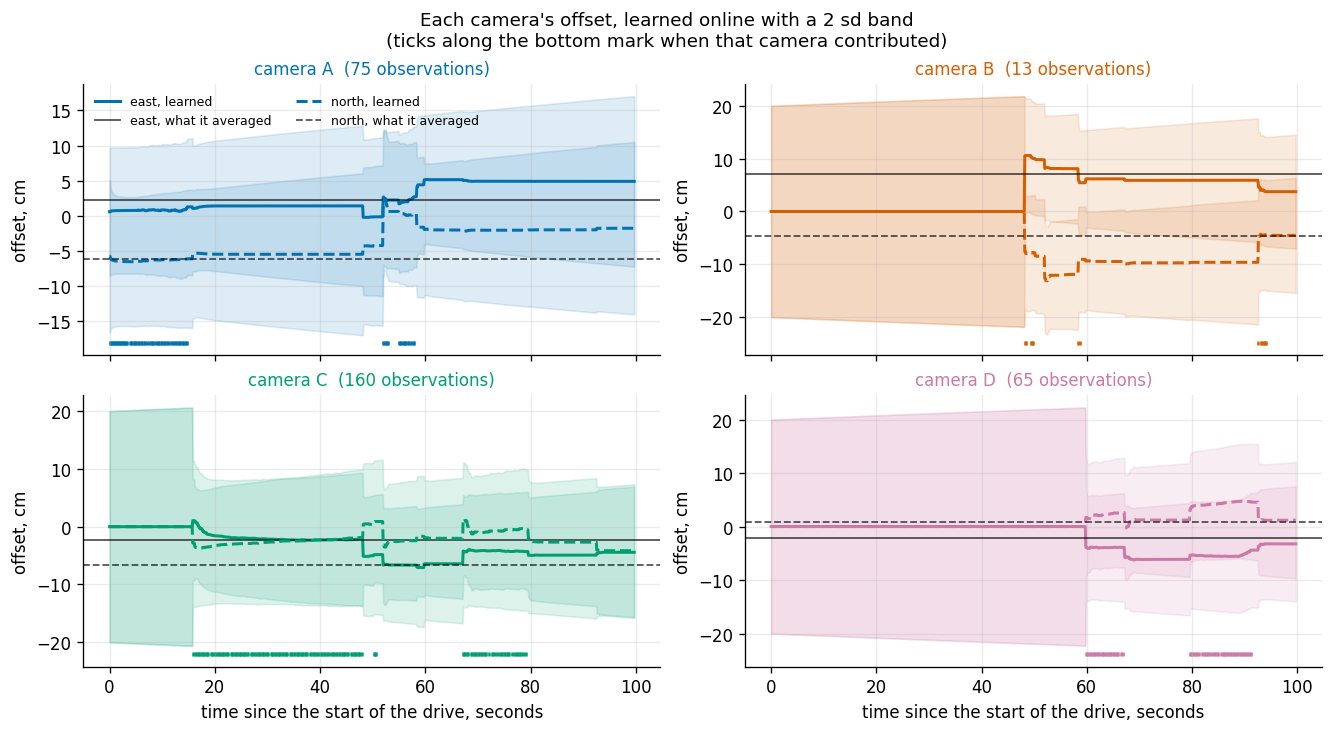

Camera B is the instructive one: it sits at its prior with a wide band until the
first observation it contributes, and its band never closes, because it contributes
only 13 of the 36 it offers. The filter is right to be unsure about it.


In [8]:
best = offset_runs["offset drifting 2 mm/step"]
time = seq.stamps - seq.stamps[0]

nv.offset_traces(seq, best, offset_runs, measured_offset, offered_per_camera, time)

### Watching the offsets being fitted

The traces show each component against time; this shows all four offsets in the plane they
actually live in, converging as the drive proceeds. Each ellipse is a camera's belief about
its own offset at that moment.

What to watch for: an offset mean changes when information reaches its block; an accepted
observation usually contracts uncertainty along directions it informs; process noise makes
uncertainty expand again while the camera is quiet. The amount is determined by the full
covariance and Kalman gain, not simply by a detection count. Camera B's ellipse remains broad.

In [9]:
nv.animate_the_offsets(seq, best, measured_offset, time)

### Three estimates related to the same residual

The next comparison is useful, but the three rows are not statistically independent:

* **measured:** the run's sample mean $\mathbf b_c$ using evaluation-only ground truth;
* **geometric:** the mean pose-dependent displacement predicted from mesh, camera model
  and odometry heading;
* **state estimate:** the final posterior mean from odometry and camera observations.

They share observations or geometry in different combinations. Agreement is therefore a
consistency check, not three independent replications. The measured row is a diagnostic
target, not an online method and not necessarily a time-varying offset's “true constant.”

  cam             measured          predicted            learned  pred err  learn err
  A    (  +2.2,  -6.2)(  +0.4,  -9.0)(  +4.9,  -1.8)      3.4c       5.2c
  B    (  +7.1,  -4.7)(  +1.4,  +2.7)(  +3.7,  -4.5)      9.4c       3.4c
  C    (  -2.2,  -6.6)(  -1.2,  -8.7)(  -4.4,  -4.2)      2.4c       3.3c
  D    (  -2.1,  +0.9)(  -2.7,  +2.6)(  -3.2,  +1.2)      1.8c       1.2c

  the part common to all four cameras: learned ( +0.2, -2.3) vs measured ( +1.2, -4.2) cm, off by 2.1 cm
  the differences between cameras, once that part is removed: median error 2.2 cm


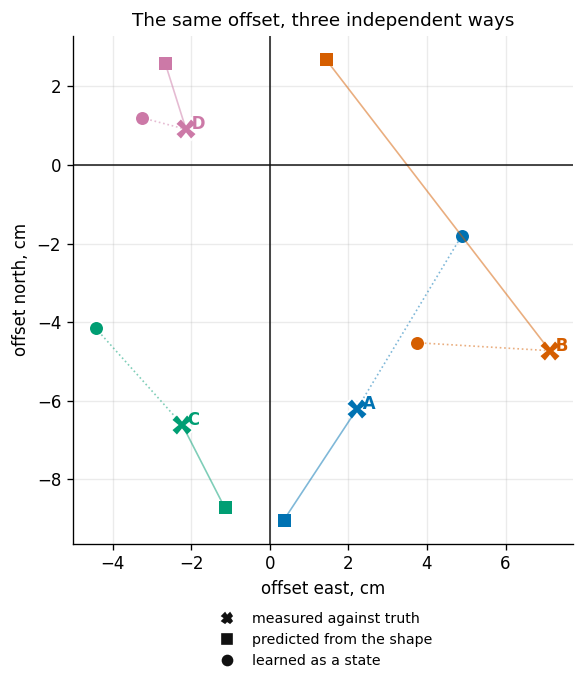

In [10]:
learned_offset = {cam: best["m"][-1, 2 + 2 * i:4 + 2 * i]
                  for i, cam in enumerate(nm.OFFSET_CAMERAS)}
geometric_offset = nm.geometric_offsets(seq, models, odom_heading)

nv.three_routes(seq, best, models, measured_offset, learned_offset, geometric_offset,
                commissioned["offset_m"])

Three things are worth taking from this.

**The belief becomes conservative even though the offsets do not become accurate.** The learned
offsets land 1 to 5 cm from what they averaged, a median of 3.3 cm on quantities of about
5 cm — not a precise estimate of the run means. Yet the position belief's median NEES moves
from 25.9 to 0.74, below the calibrated 2-D reference 1.386. That is not a contradiction:
the filter now carries
the *uncertainty* in the offsets through into the position, so it stops claiming precision
it does not have. Accuracy of the posterior mean and calibration of the posterior covariance
are different properties.

**What is identifiable is what the observation graph makes identifiable.** The part common to all four
offsets is invisible to the cameras by construction, and comes out 2.1 cm off; the
differences between cameras recover to 2.2 cm. Those relative constraints exist because
the route and odometry connect the cameras' observation intervals through a shared
trajectory. If the camera–time graph were disconnected, offsets in different components
would acquire additional independent gauge freedoms. This is a property of the data design,
not a magic property of the Kalman filter.

**Prediction and state estimation are not rivals, and they fail in different places.** Predicting
from the shape gives the better position — 3.7 cm against 5.3 cm — because it knows the
mechanism, including how the offset swings as the robot turns. But look at the per-camera
errors: the predictor is excellent on A, C and D (1.8 to 3.4 cm) and poor on **B (9.4 cm)**,
the camera whose silhouette is clipped by shelving most often, where its assumption that
the whole robot is visible breaks. The constant-state model lacks that full-silhouette
assumption and is closer to the evaluation-only run mean there (3.4 cm). The principled
next model is therefore a hybrid: predict the explainable pose-dependent term, then estimate
and validate a residual term with uncertainty. This diagnostic run motivates that hybrid;
it does not by itself validate one.

---

*One recorded Gazebo session, one clock, no synthetic data. All estimator functions are
shared through `notebook_model.py` and all figures through `notebook_views.py`. Ground truth
fields are evaluation-only.*